# Laboratory 5 - Systems of linear equation
#### Grzegorz Fotyga

## 1 Introduction

The aim of the following laboratory is to use various algorithms to solve systems of linear equations. The analyzed systems of equations are related to the PageRank algorithm, which was discussed in previous classes. In this laboratory, it is crucial to observe the effectiveness of individual algorithms.


### Task 1

The following code is used to generate the matrix: Edges. It contains links in a network of sites. Based on the connections, we generate matrices related to the PageRank algorithm. Solving the system of linear equations will allow you to determine the ranking of the pages (just like in the previous classes). Note - the codes below are only for generating Edges arrays. Understanding them is not necessary to complete subsequent tasks.

Generate network with 2000 sites and dnsity of connection: 20. 

In [5]:
import numpy as np

def remove_duplicate_columns(matrix):
    unique_columns = np.unique(matrix, axis=1)
    return unique_columns

def generate_network(N, density):
    Edges = np.random.randint(1, N+1, size=(2, int(N * density)))
    Edges = np.delete(Edges, np.where(Edges[0] == Edges[1]), axis=1)
    Edges = remove_duplicate_columns(Edges)
    return Edges

n = 2000  # number of sites
density = 20  # density of connections in the network
Edges = generate_network(n, density)
print("number of connections in the network:", Edges.shape[1])  # print number of connections

number of connections in the network: 39795


### Task 2

Generate matrices related to the PageRank algorithm based on the network. Create an appropriate function that generates PageRank matrices and can be used in subsequent tasks.

In [15]:
from scipy.sparse import csr_matrix
from scipy.sparse import identity
import matplotlib.pyplot as plt 

def generate_pagerank_matrices(Edges, n, d):
    d = 0.1  # dumping factor
    b = np.ones(n) * (1-d)/n
    I = identity(n, format='csr')

    B = csr_matrix((n,n))
    B[Edges[1] - 1, Edges[0] - 1] = 1

    L = np.zeros(n)
    for i in range(n):
        L[i] = np.sum(B[:,i])

    A = csr_matrix((n,n))
    for i in range(n):
        A[i,i] = 1/L[i]
    M = I - d * B @ A

    return I, B, L, M, b

### Task 3

- Solve Page Rank system of equations $\mathbf{M}\mathbf{r} = \mathbf{b}$ using *inv()* funcion from *scipy* module: $\mathbf{r} = \mathbf{M}^{-1}\mathbf{b}$. Save $\mathbf{r}$ for comparison with other methods.

- Measure the time needed for this operation (and save it for comparison with other methods).

- (and promise that this lab will be the last time you solve a system of equations this way!)

- Use function *plt.spy()* with parameter: *markersize=0.1* to observe nonzero elements of $\mathbf{M}$ and $\mathbf{M}^{-1}$ matrices. Check the memory usage of both matrices. Comment these results. 

c:\Users\marta\OneDrive\Documents\programming\NumericalMethodsLabs\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\marta\OneDrive\Documents\programming\NumericalMethodsLabs\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Time using inv(): 9.235827684402466
r from inv():
[0.00049499 0.0004862  0.0004745  ... 0.00049332 0.00049234 0.000507  ]


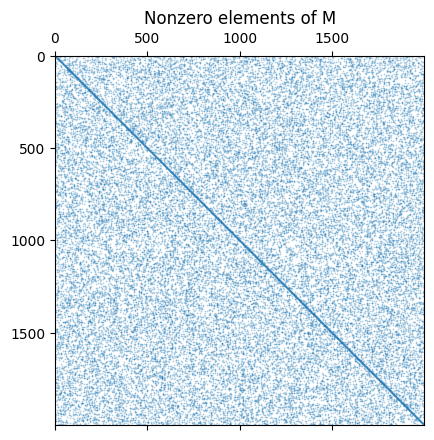

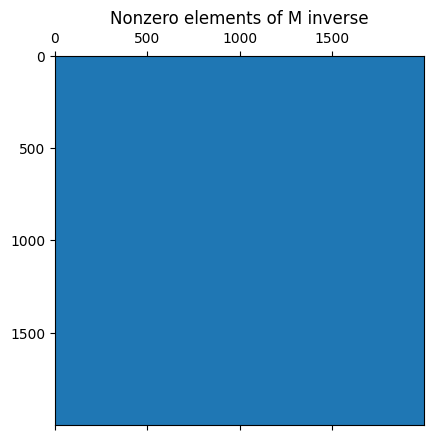

Memory usage of M: 509544 bytes
Memory usage of M inverse: 48008004 bytes


In [ ]:
from scipy.sparse.linalg import inv

# your code

import time
import matplotlib.pyplot as plt

start = time.time()

M_inv = inv(M)
r_inv = M_inv @ b

time_inv = time.time() - start

print("Time using inv():", time_inv)
print("r from inv():")
print(r_inv)

plt.figure()
plt.spy(M, markersize=0.1)
plt.title("Nonzero elements of M")
plt.show()

plt.figure()
plt.spy(M_inv, markersize=0.1)
plt.title("Nonzero elements of M inverse")
plt.show()

memory_M = M.data.nbytes + M.indices.nbytes + M.indptr.nbytes
memory_M_inv = M_inv.data.nbytes + M_inv.indices.nbytes + M_inv.indptr.nbytes

In [ ]:
import sys 
memory_usage = M.data.nbytes + M.indices.nbytes + M.indptr.nbytes
print("Memory usage of CSR matrix:", memory_usage, "bytes")
print("Memory usage of CSR inverse:", memory_M_inv, "bytes")

# Matrix M is sparse and uses relatively little memory
# However its inverse is much denser
# This shows that computing the inverse directly is inefficient

Memory usage of CSR matrix: 509544 bytes
Memory usage of CSR inverse: 48008004 bytes


Your commens:

### Task 4

- Solve the same system of equations using direct method: *spsolve()*. Save $\mathbf{r}$ for comparison with other methods.
- Measure the time needed for this operation (and save it for comparison with other methods).
- Use plt.plot() function to show the difference between solutions obtained in previous tasks. What is the maximum value of the difference between these vectors?
- Compute the norm (*np.linalg.norm()*) of the the difference between these two vectors. 

In [ ]:
from scipy.sparse.linalg import spsolve

# your code

import time
import numpy as np
import matplotlib.pyplot as plt

start = time.time()

r_spsolve = spsolve(M, b)

time_spsolve = time.time() - start

print("Time using spsolve():", time_spsolve)
print("r from spsolve():")
print(r_spsolve)

difference = r_inv - r_spsolve

plt.figure()
plt.plot(difference)
plt.title("Difference between inv() and spsolve() solutions")
plt.xlabel("Page")
plt.ylabel("Difference")
plt.grid(True)
plt.show()

max_difference = np.max(np.abs(difference))
norm_difference = np.linalg.norm(difference)

print("Maximum difference:", max_difference)
print("Norm of difference:", norm_difference)

# The solutions gotten from using inv() and spsolve() are almost identical numerically
# But spsolve() is more effective because it solves the system directly without explicitly computing the inverse matrix, so it is faster and uses less memory

### Task 5

In this task you will implement Jacobi mathod. Firstly, split $\mathbf{M}$ into 3 components: *$\textbf{M} = -\textbf{L} - \textbf{U} + \textbf{D}$*

- $\textbf{L}$ contains all elements of $\mathbf{M}$, which lie below the diagonal (without diagonal). It can be computed using *tril()*, with parameter *k = -1*, wchich means that we do not include elements from diagonal. 

- $\textbf{U}$ contains all elements of $\mathbf{M}$, which lie above the diagonal (without diagonal). It can be computed using *triu()*, with parameter *k = 1*, wchich means that we do not include elements from diagonal. 

- $\textbf{D}$ contains all elements of $\mathbf{M}$, which lie at the diagonal. In our case it is just identity matrix. 

- Use *spy()* to observe nonzero elements. 


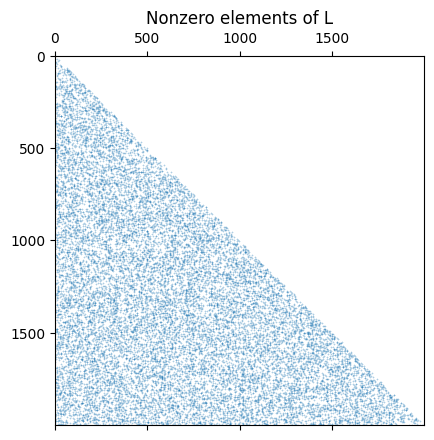

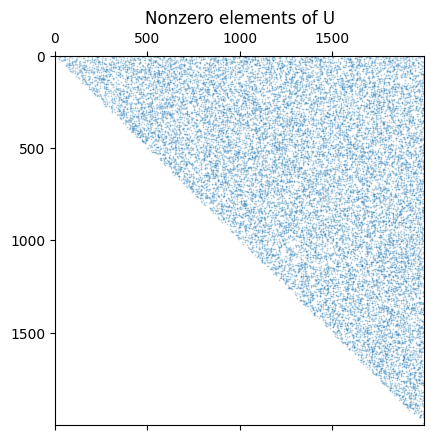

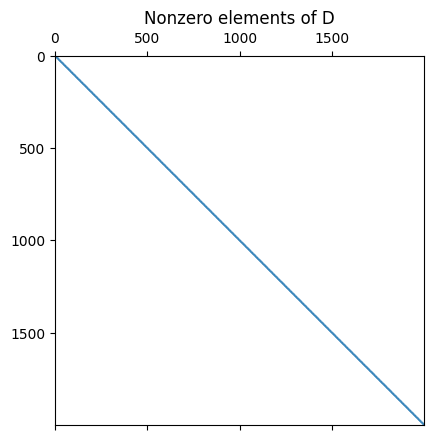

In [19]:
from scipy.sparse import csr_matrix, triu, tril

# your code

import matplotlib.pyplot as plt

# M = -L - U + D
L = -tril(M, k=-1)
U = -triu(M, k=1)
D = identity(n, format='csr') # in this task D is identity matrix

plt.figure()
plt.spy(L, markersize=0.1)
plt.title("Nonzero elements of L")
plt.show()

plt.figure()
plt.spy(U, markersize=0.1)
plt.title("Nonzero elements of U")
plt.show()

plt.figure()
plt.spy(D, markersize=0.1)
plt.title("Nonzero elements of D")
plt.show()

### Task 6 - Jacobi

- Generate $\mathbf{r}^0$ vector of the same size as $\mathbf{b}$ vector, which is full of ones. It will be used as a starting vector for Jacobi scheme. 
- Use Jacobi scheme to solve system of equations in iterative way: $\widetilde{\textbf{r}}^{n+1} = \textbf{D}^{-1}(\textbf{L} + \textbf{U})\widetilde{\textbf{r}}^{n} + \textbf{D}^{-1}\textbf{b}$	

- Hint: $\mathbf{D}$ is an identity matrix. Do you need to explicitely compute $\mathbf{D}^{-1}$? 
- In each iteration compute the real error ($\textbf{e}^n = \textbf{r} - \widetilde{\textbf{r}}^{n} $, where $\textbf{r}$ is a solution obtained using the direct scheme (task 4)) and the residual error ($\textbf{res}^n = \textbf{M}\widetilde{\textbf{r}}^n - \textbf{b}$)
- Observe the NORM of these error vectors in subsequent iterations. 
- Stop iterative scheme once the NORM of the residual error falls below the value 1e-12.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# starting vector full of ones
r_jacobi = np.ones(n)

real_errors = []
residual_errors = []

max_iterations = 10000
tolerance = 1e-12

for iteration in range(max_iterations):
    # because D is identity, D^-1 is also identity
    r_new = (L + U) @ r_jacobi + b

    real_error = r_spsolve - r_new
    residual_error = M @ r_new - b

    real_error_norm = np.linalg.norm(real_error)
    residual_error_norm = np.linalg.norm(residual_error)

    real_errors.append(real_error_norm)
    residual_errors.append(residual_error_norm)

    r_jacobi = r_new

    if residual_error_norm < tolerance:
        break

print("Number of iterations:", iteration + 1)
print("Final residual error norm:", residual_errors[-1])
print("Final real error norm:", real_errors[-1])
print("Jacobi result:")
print(r_jacobi)

NameError: name 'r_spsolve' is not defined

### Task 7

Compare the computational times of three methods: inv, direct and Jacobi.  

In [22]:
print("Time comparison:")
print("inv():     ", time_inv)
print("spsolve(): ", time_spsolve)
print("Jacobi:    ", time_jacobi)

Time comparison:
inv():      9.235827684402466


NameError: name 'time_spsolve' is not defined

### Task 8 - additional

implement Gauss - Seidel scheme.
 
$\widetilde{\textbf{r}}^{n+1} = (\textbf{D -L})^{-1}(\textbf{U} \widetilde{\textbf{r}}^{n}) + (\textbf{D -L})^{-1}\textbf{b}$

In [23]:
# your code
from scipy.sparse.linalg import spsolve
import numpy as np
import time

start = time.time()

r_gs = np.ones(n)

gs_real_errors = []
gs_residual_errors = []

max_iterations = 10000
tolerance = 1e-12

DL = D - L

for iteration_gs in range(max_iterations):
    r_new = spsolve(DL, U @ r_gs + b)

    real_error = r_spsolve - r_new
    residual_error = M @ r_new - b

    gs_real_errors.append(np.linalg.norm(real_error))
    gs_residual_errors.append(np.linalg.norm(residual_error))

    r_gs = r_new

    if gs_residual_errors[-1] < tolerance:
        break

time_gauss_seidel = time.time() - start

print("Gauss-Seidel time:", time_gauss_seidel)
print("Gauss-Seidel iterations:", iteration_gs + 1)
print("Final residual error:", gs_residual_errors[-1])

print("Time comparison:")
print("inv():          ", time_inv)
print("spsolve():      ", time_spsolve)
print("Jacobi:         ", time_jacobi)
print("Gauss-Seidel:   ", time_gauss_seidel)

NameError: name 'r_spsolve' is not defined